# Introduction to LCEL and LangGraph: LangChain Powered RAG

In the following notebook we're going to focus on learning how to navigate and build useful applications using LangChain, specifically LCEL, and how to integrate different APIs together into a coherent RAG application!

We'll be building a RAG system to answer querys about how people use AI, using the "How People Use AI" dataset.

In the notebook, you'll complete the following Tasks:

- 🤝 Breakout Room #2:
    1. LangChain and LCEL Concepts
    2. Understanding States and Nodes
    3. Introduction to QDrant Vector Databases
    4. Building a Basic Graph

Let's get started!



## Installation Requirements

Also, make sure Ollama is installed and running with the required models pulled (see instructions below).


## Optional: LangSmith Setup for Tracing and Monitoring

LangSmith provides powerful tracing, monitoring, and debugging capabilities for LangChain applications. While not required for this notebook, setting it up will give you valuable insights into your RAG system's performance.

### Getting LangSmith Credentials

1. **Sign up for LangSmith**: Visit [smith.langchain.com](https://smith.langchain.com) and create a free account
2. **Get your API Key**: 
   - Go to Settings → API Keys
   - Create a new API key and copy it
3. **Set your environment variables** (choose one method below):

**Option A: Set environment variables in your terminal before starting Jupyter:**
```bash
export LANGCHAIN_TRACING_V2=true
export LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")
export LANGCHAIN_PROJECT="RAG-Assignment"
```

**Option B: Set them in the notebook (run the cell below):**


In [1]:
# Optional: Set up LangSmith tracing
# Uncomment and fill in your credentials if you want to use LangSmith

import os
import getpass
import os
from dotenv import load_dotenv
load_dotenv()

# Uncomment the lines below to enable LangSmith tracing
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "RAG-Assignment"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

# Verify setup (uncomment to check)
print("LangSmith tracing enabled:", os.getenv("LANGCHAIN_TRACING_V2", "false"))
print("Project name:", os.getenv("LANGCHAIN_PROJECT", "Not set"))


LangSmith tracing enabled: true
Project name: RAG-Assignment


### What LangSmith Provides

Once set up, LangSmith will automatically trace your LangChain operations and provide:

- **Execution traces**: See exactly how your RAG pipeline processes each query
- **Performance metrics**: Monitor latency, token usage, and costs
- **Debugging tools**: Inspect intermediate outputs at each step
- **Error tracking**: Identify and debug issues in your chains
- **Dataset management**: Collect and organize your queries and responses

You can view all traces and analytics in your LangSmith dashboard at [smith.langchain.com](https://smith.langchain.com).

> **Note**: LangSmith is completely optional for this assignment. The notebook will work perfectly fine without it, but it's a valuable tool for production applications.


# 🤝 Breakout Room #2

## Set Up Ollama

We'll be using Ollama to run local LLM models. Make sure you have Ollama installed and running:

1. Install Ollama from https://ollama.ai (`curl https://ollama.ai/install.sh | sh`)
2. Make sure the output of `ollama -v` reads `0.11.10` or greater.
2. Pull the models we'll use:
   ```bash
   ollama pull gpt-oss:20b # For the chat model
   ollama pull embeddinggemma:latest  # For embeddings
   ```
3. Ensure Ollama is running (it should start automatically after installation)

### A Note On Runnables

# Understanding LangChain Runnables and LCEL

In LangChain, a Runnable is like a LEGO brick in your AI application - it's a standardized component that can be easily connected with other components. The real power of Runnables comes from their ability to be combined in flexible ways using LCEL (LangChain Expression Language).

## Key Features of Runnables

### 1. Universal Interface
Every Runnable in LangChain follows the same pattern:
- Takes an input
- Performs some operation
- Returns an output

This consistency means you can treat different components (like models, retrievers, or parsers) in the same way.

### 2. Built-in Parallelization
Runnables come with methods for handling multiple inputs efficiently:
```python
# Process inputs in parallel, maintain order
results = chain.batch([input1, input2, input3])

# Process inputs as they complete
for result in chain.batch_as_completed([input1, input2, input3]):
    print(result)
```

### 3. Streaming Support
Perfect for responsive applications:
```python
# Stream outputs as they're generated
for chunk in chain.stream({"query": "Tell me a story"}):
    print(chunk, end="", flush=True)
```

### 4. Easy Composition
The `|` operator makes building pipelines intuitive:
```python
# Create a basic RAG chain
rag_chain = retriever | prompt | model | output_parser
```

## Common Types of Runnables

- **Language Models**: Like our `ChatOllama` instance (running locally with Ollama)
- **Prompt Templates**: Format inputs consistently
- **Retrievers**: Get relevant context from a vector store
- **Output Parsers**: Structure model outputs
- **LangGraph Nodes**: Individual components in our graph

Think of Runnables as the building blocks of your LLM application. Just like how you can combine LEGO bricks in countless ways, you can mix and match Runnables to create increasingly sophisticated applications!



## LangGraph Based RAG

Now that we have a reasonable grasp of LCEL and the idea of Runnables - let's see how we can use LangGraph to build the same system!

### Primer: What is LangGraph?
LangGraph is a tool that leverages LangChain Expression Language to build coordinated multi-actor and stateful applications that includes cyclic behaviour.

#### Why Cycles?
In essence, we can think of a cycle in our graph as a more robust and customizable loop. It allows us to keep our application agent-forward while still giving the powerful functionality of traditional loops.

Due to the inclusion of cycles over loops, we can also compose rather complex flows through our graph in a much more readable and natural fashion. Effectively allowing us to recreate application flowcharts in code in an almost 1-to-1 fashion.

#### Why LangGraph?
Beyond the agent-forward approach - we can easily compose and combine traditional "DAG" (directed acyclic graph) chains with powerful cyclic behaviour due to the tight integration with LCEL. This means it's a natural extension to LangChain's core offerings!

> NOTE: We're going to focus on building a simple DAG for today's assignment as an introduction to LangGraph

### Putting the State in Stateful

Earlier we used this phrasing:

> coordinated multi-actor and stateful applications

So what does that "stateful" mean?

To put it simply - we want to have some kind of object which we can pass around our application that holds information about what the current situation (state) is. Since our system will be constructed of many parts moving in a coordinated fashion - we want to be able to ensure we have some commonly understood idea of that state.

LangGraph leverages a `StatefulGraph` which uses an `AgentState` object to pass information between the various nodes of the graph.

There are more options than what we'll see below - but this `AgentState` object is one that is stored in a `TypedDict` with the key `messages` and the value is a `Sequence` of `BaseMessages` that will be appended to whenever the state changes.

However, in our example here, we're focusing on a simpler `State` object:

```python
class State(TypedDict):
    query: str
    context: list[Document]
    response: str
```

Let's think about a simple example to help understand exactly what this means (we'll simplify a great deal to try and clearly communicate what state is doing):

1. **We initialize our state object**:
   ```python
   {
       "query": "",
       "context": [],
       "response": ""
   }
   ```

2. **Our user submits a query to our application.**  
   We store the user's query in `state["query"]`. Now we have:
   ```python
   {
       "query": "How tall is the Eiffel Tower?",
       "context": [],
       "response": ""
   }
   ```

3. **We pass our state object to an Agent node** which is able to read the current state. It will use the value of `state["query"]` as input and might retrieve some context documents related to the query. It then generates a response which it stores in `state["response"]`. For example:
   ```python
   {
       "query": "How tall is the Eiffel Tower?",
       "context": [Document(page_content="...some data...")],
       "response": "The Eiffel Tower is about 324 meters tall..."
   }
   ```

That's it! The important part is that we have a consistent object (`State`) that's passed around, holding the crucial information as we go from one node to the next. This ensures our application has a single source of truth about what has happened so far and what is happening now.



In [2]:
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  query: str
  context: list[Document]
  response: str

Now that we have state, and we have tools, and we have an LLM - we can finally start making our graph!

Let's take a second to refresh ourselves about what a graph is in this context.

Graphs, also called networks in some circles, are a collection of connected objects.

The objects in query are typically called nodes, or vertices, and the connections are called edges.

Let's look at a simple graph.

![image](https://i.imgur.com/2NFLnIc.png)

Here, we're using the coloured circles to represent the nodes and the yellow lines to represent the edges. In this case, we're looking at a fully connected graph - where each node is connected by an edge to each other node.

If we were to think about nodes in the context of LangGraph - we would think of a function, or an LCEL Runnable.

If we were to think about edges in the context of LangGraph - we might think of them as "paths to take" or "where to pass our state object next".  

### Building Nodes

We're going to need two nodes:

A node for retrieval, and a node for generation.

Let's start with our `retrieve` node!

Notice how we do not need to update the state object in the node, but can instead return a modification directly to our state.

#### Building a Retriever with LangChain

In order to build our `retrieve` node, we'll first need to build a retriever!

This will involve the following steps: 

1. Ingesting Data
2. Chunking the Data
3. Vectorizing the Data and Storing it in a Vector Database
4. Converting it to a Retriever

##### Retreiver Step 1: Ingesting Data

In today's lesson, we're going to be building a RAG system to answer querys about how people use AI - and we will pull information into our index (vectorized chunks stored in our vector store) through LangChain's [`PyMuPDFLoader`](https://python.langchain.com/api_reference/community/document_loaders/langchain_community.document_loaders.pdf.PyMuPDFLoader.html)!

> NOTE: We'll be using an async loader during our document ingesting - but our Jupyter Kernel is already running in an asyc loop! This means we'll want the ability to *nest* async loops. 

In [3]:
import nest_asyncio

nest_asyncio.apply()

Now, we're good to load our documents through the [`PyMuPDFLoader`](https://python.langchain.com/api_reference/community/document_loaders/langchain_community.document_loaders.pdf.PyMuPDFLoader.html)!

In [4]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

ai_usage_knowledge_resources = directory_loader.load()

In [5]:
ai_usage_knowledge_resources[0].page_content[:1000]

'NBER WORKING PAPER SERIES\nHOW PEOPLE USE CHATGPT\nAaron Chatterji\nThomas Cunningham\nDavid J. Deming\nZoe Hitzig\nChristopher Ong\nCarl Yan Shan\nKevin Wadman\nWorking Paper 34255\nhttp://www.nber.org/papers/w34255\nNATIONAL BUREAU OF ECONOMIC RESEARCH\n1050 Massachusetts Avenue\nCambridge, MA 02138\nSeptember 2025\nWe acknowledge help and comments from Joshua Achiam, Hemanth Asirvatham, Ryan \nBeiermeister, Rachel Brown, Cassandra Duchan Solis, Jason Kwon, Elliott Mokski, Kevin Rao, \nHarrison Satcher, Gawesha Weeratunga, Hannah Wong, and Analytics & Insights team. We \nespecially thank Tyna Eloundou and Pamela Mishkin who in several ways laid the foundation for \nthis work. This study was approved by Harvard IRB (IRB25-0983). A repository containing all \ncode run to produce the analyses in this paper is available on request. The views expressed herein \nare those of the authors and do not necessarily reflect the views of the National Bureau of \nEconomic Research.\nAt least one c

#### TextSplitting aka Chunking

We'll use the `RecursiveCharacterTextSplitter` to create our toy example.

It will split based on the following rules:

- Each chunk has a maximum size of 1000 tokens
- It will try and split first on the `\n\n` character, then on the `\n`, then on the `<SPACE>` character, and finally it will split on individual tokens.

Let's implement it and see the results!

In [6]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    # Using cl100k_base encoding which is a good general-purpose tokenizer
    # This works well for estimating token counts even with Ollama models
    tokens = tiktoken.get_encoding("cl100k_base").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)

In [7]:
ai_usage_knowledge_chunks = text_splitter.split_documents(ai_usage_knowledge_resources)

##### 🏗️ Activity #1:

While there's nothing specifically wrong with the chunking method used above - it is a naive approach that is not sensitive to specific data formats.

Brainstorm some ideas that would split large single documents into smaller documents.

1. Document based chunking - Each logical document becomes its own chunk
2. Semantic based chunking - Use an embedding model to find "natural" breaks where topic shifts occur.
3. Metadata-aware chunking - Split based on document structure (headers, sections, page breaks)

#### Embeddings and Dense Vector Search

Now that we have our individual chunks, we need a system to correctly select the relevant pieces of information to answer our query.

This sounds like a perfect job for embeddings!

We'll be using Ollama's `embeddinggemma` model as our embedding model today! This is a powerful open-source embedding model that runs locally.

Let's load it up through LangChain.

In [14]:
from langchain_ollama import OllamaEmbeddings
 
# Using embeddinggemma which is a powerful open-source embedding model
embedding_model = OllamaEmbeddings(model="embeddinggemma:latest")

##### ❓ query #1:

What is the embedding dimension, given that we're using `embeddinggemma`?

You will need to fill the next cell out correctly with your embedding dimension for the rest of the notebook to run.

In [15]:
embedding_dim = 768

#### Using A Vector Database - Intoduction to Qdrant

Up to this point, we've been using a dictionary to hold our embeddings - typically, we'll want to use a more robust strategy.

In this bootcamp - we'll be focusing on leveraging [Qdrant's vector database](https://qdrant.tech/qdrant-vector-database/).

Let's take a look at how we set-up Qdrant!

> NOTE: We'll be spending a lot of time learning about Qdrant throughout the remainder of our time together - but for an initial primer, please check out [this resource](https://qdrant.tech/articles/what-is-a-vector-database/)

We are going to be using an "in-memory" Qdrant client, which means that our vectors will be held in our system's memory (RAM) - this is useful for prototyping and developement at smaller scales - but would need to be modified when moving to production. Luckily for us, this modification is trivial!

> NOTE: While LangChain uses the terminology "VectorStore" (also known as a Vector Library), Qdrant is a "Vector Database" - more info. on that [here.](https://weaviate.io/blog/vector-library-vs-vector-database)

In [16]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

Next, we need to create a collection - a collection is a specific...collection of vectors within the Qdrant client.

These are useful as they allow us to create multiple different "warehouses" in a single client, which can be leveraged for personalization and more!

Also notice that we define what our vector shapes are (embedding dim) as well as our desired distance metric.

In [17]:
client.create_collection(
    collection_name="ai_usage_knowledge_index",
    vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE),
)

True

Now we can assemble our vector database! Notice that we provide our client, our created collection, and our embedding model!

In [18]:
vector_store = QdrantVectorStore(
    client=client,
    collection_name="ai_usage_knowledge_index",
    embedding=embedding_model,
)

Now that we have our vector database set-up, we can add our documents into it!

In [19]:
_ = vector_store.add_documents(documents=ai_usage_knowledge_chunks)

#### Creating a Retriever

Now that we have an idea of how we're getting our most relevant information - let's see how we could create a pipeline that would automatically extract the closest chunk to our query and use it as context for our prompt!

This will involve a popular LangChain interace known as `as_retriever`!

> NOTE: We can still specify how many documents we wish to retrieve per vector.

In [20]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

In [21]:
retriever.invoke("How do people use AI in their daily work?")

[Document(metadata={'producer': 'macOS Version 15.4.1 (Build 24E263) Quartz PDFContext, AppendMode 1.1', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-09-12T20:05:32+00:00', 'source': 'data/howpeopleuseai.pdf', 'file_path': 'data/howpeopleuseai.pdf', 'total_pages': 64, 'format': 'PDF 1.6', 'title': 'How People Use ChatGPT', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-09-15T10:32:36-04:00', 'trapped': '', 'modDate': "D:20250915103236-04'00'", 'creationDate': 'D:20250912200532Z', 'page': 34, '_id': '67834dfcc0914deab9c5cb016e8f0a73', '_collection_name': 'ai_usage_knowledge_index'}, page_content='Panel A. Work Related\nPanel B1. Asking.\nPanel B2. Doing.\nFigure 23: (continued on next page)\n33'),
 Document(metadata={'producer': 'macOS Version 15.4.1 (Build 24E263) Quartz PDFContext, AppendMode 1.1', 'creator': 'LaTeX with hyperref', 'creationdate': '2025-09-12T20:05:32+00:00', 'source': 'data/howpeopleuseai.pdf', 'file_path': 'data/howpeopleuseai.pdf', 'total_

#### Creating the Node

We're finally ready to create our node!

In [22]:
def retrieve(state: State) -> State:
  retrieved_docs = retriever.invoke(state["query"])
  return {"context" : retrieved_docs}

### Generate Node

Next, let's create our `generate` node - which will leverage LangChain and something called an "LCEL Chain" which you can read more about [here](https://python.langchain.com/docs/concepts/lcel/)!

We'll want to create a chain that does the following: 

1. Formats our inputs into a chat template suitable for RAG
2. Takes that chat template and sends it to an LLM
3. Parses that output into `str` format

Let's get chaining!

#### Chain Components: RAG Chat Template

We'll create a chat template that takes in some query and formats it as a RAG prompt using LangChain's prompt template!

In [23]:
from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context response with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

In [24]:
chat_prompt.invoke({"context" : "OUR CONTEXT HERE", "query" : "OUR QUERY HERE"}).messages[0].content

'\n#CONTEXT:\nOUR CONTEXT HERE\n\nQUERY:\nOUR QUERY HERE\n\nUse the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it\'s not contained in the provided context response with "I don\'t know"\n'

##### Chain Components: Generator

We'll next set-up the generator - which will be Ollama's `gpt-oss:20b` model running locally!

In [25]:
from langchain_ollama import ChatOllama

# Using gpt-oss:20b which is a powerful and efficient local model
ollama_chat_model = ChatOllama(model="llama3.1:8b", temperature=0.6)

Let's now call our model with a formatted prompt.

Notice that we have some nested calls here - we'll see that this is made easier by LCEL.

In [26]:
ollama_chat_model.invoke(chat_prompt.invoke({"context" : "Paris is the capital of France", "query" : "What is the capital of France?"}))

AIMessage(content='Paris is the capital of France.', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-09-23T18:32:06.314577Z', 'done': True, 'done_reason': 'stop', 'total_duration': 19429443149, 'load_duration': 9403518262, 'prompt_eval_count': 75, 'prompt_eval_duration': 8080408870, 'eval_count': 8, 'eval_duration': 1928962655, 'model_name': 'llama3.1:8b'}, id='run--9774a5c0-1bee-499e-ba7b-66b5796ac885-0', usage_metadata={'input_tokens': 75, 'output_tokens': 8, 'total_tokens': 83})

#### Chain Components: `str` Parser

Finally, let's set-up our `StrOutputParser()` which will transform our model's output into a simple `str` to be provided to the user.

> NOTE: You can see us leveraging LCEL in the example below to avoid needing to do nested calls.

In [27]:
from langchain_core.output_parsers import StrOutputParser

generator_chain = chat_prompt | ollama_chat_model | StrOutputParser()

generator_chain.invoke({"context" : "Paris is the capital of France", "query" : "What is the capital of France?"})

'Paris is the capital of France.'

### `generate` Node: 

Now we can create our `generate` Node!

In [28]:
def generate(state: State) -> State:
  generator_chain = chat_prompt | ollama_chat_model | StrOutputParser()
  response = generator_chain.invoke({"query" : state["query"], "context" : state["context"]})
  return {"response" : response}

Now we can start defining our graph!

Think of the graph's state as a blank canvas that we can add nodes and edges to.

Every graph starts with two special nodes - START and END - the act as the entry and exit point to the other nodes in the graphs.  

All valid graphs must start at the START node and end at the END node.

In [29]:
# Start with the blank canvas
graph_builder = StateGraph(State)

Now we can add a sequence to our "canvas" (graph) - this can be done by providing a list of nodes, the will automatically have edges that connect the i-th element to the i+1-th element in the list. The final element will be added to the END node unless otherwise specified.

In [30]:
graph_builder = graph_builder.add_sequence([retrieve, generate])

Next, let's connect our START node to our `retrieve` node by adding an edge.

In [31]:
graph_builder.add_edge(START, "retrieve")

Finally we can compile our graph! This will do basic verification to ensure that the Runnables have the correct inputs/outputs and can be matched.

In [32]:
graph = graph_builder.compile()

Finally, we can visualize our graph!

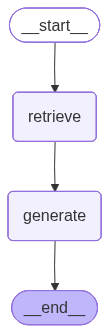

In [33]:
graph

Let's take it for a spin!

We invoke our graph like we do any other Runnable in LCEL!

> NOTE: That's right, even a compiled graph is a Runnable!

In [34]:
from IPython.display import Markdown, display, Image
response = graph.invoke({"query" : "What are the most common ways people use AI in their work?"})
display(Markdown(response["response"]))

The provided context does not directly answer the question of how people commonly use AI in their work. However, we can infer some information from the text.

From the document on page 53, we see examples of users rewriting emails to be more friendly or complaining about grandmothers, which suggests that AI is being used for tasks such as language processing and potentially customer service or support.

Additionally, on page 37, it mentions "in knowledge-intensive jobs where productivity is increasing in the quality of decision-making," implying that AI may be used in certain industries to enhance decision-making processes.

However, the most direct information about how people use AI in their work comes from the document on page 53, which provides examples of user interactions with AI. It lists specific tasks such as rewriting emails, complaining, and asking for help fixing errors, indicating that users are leveraging AI for a variety of tasks, including language processing and technical support.

It's worth noting that this information is based on the provided context and may not be comprehensive or representative of all uses of AI in work settings.

In [ ]:
response = graph.invoke({"query" : "Do people use AI for their personal lives?"})
display(Markdown(response["response"]))

Based on the provided context, I can see that there is a document with page content containing examples of how people use AI, including:

* Rewriting emails to be more friendly
* Complaining about grandmothers
* Asking for help fixing Python errors

However, none of these examples are related to personal lives. The text only mentions work-related tasks or interactions.

Therefore, I don't have enough information to answer the user's query about whether people use AI for their personal lives. 

I don't know

In [ ]:
response = graph.invoke({"query" : "What concerns or challenges do people have when using AI?"})
display(Markdown(response["response"]))

Based on the provided context, I found a relevant passage that might address the user's question:

"Ling, Yier and Alex Imas, “Underreporting of AI use: The role of social desirability bias,” https:\n//ssrn.com/abstract=5232910 May 2025.\nAvailable at SSRN: https://ssrn.com/abstract=\n5232910 or http://dx.doi.org/10.2139/ssrn.5232910.\n38"

However, this passage does not directly answer the question about concerns or challenges when using AI. It appears to be a citation for an academic paper related to AI use.

Another relevant passage is:

"9Zao-Sanders (2025) is based on a manual collection and labeling of online resources (Reddit, Quora, online articles),\nand so we believe it likely resulted in an unrepresentative distribution of use cases.\n10Among those with names commonly associated with a particular gender.\n11Appendix A gives the full prompt text and Appendix B gives detail about how the prompts were validated against\npublic conversation data.\n3"

This passage mentions that Zao-Sanders (2025) might have resulted in an unrepresentative distribution of AI use cases, but it does not directly address concerns or challenges when using AI.

Unfortunately, I couldn't find any direct answer to the user's question within the provided context. Therefore, my response is:

I don't know

In [ ]:
response = graph.invoke({"query" : "Who is Batman?"})
display(Markdown(response["response"]))

I don't know. The context appears to be a PDF document about how people use AI, and there is no mention of Batman.

#### ❓ query #2:
LangGraph's graph-based approach lets us visualize and manage complex flows naturally. How could we extend our current implementation to handle edge cases? For example:
- What if the retriever finds no relevant context?  
- What if the response needs fact-checking?
Consider how you would modify the graph to handle these scenarios.

##### ✅ Answers
2.1 #Your answer here<br>
2.1.1) Conditional routing based on relevance thresholds<br>
2.1.2) Fallback to external search when interanl context is insufficient<br>
2.1.3) A dedidcated no-context response generation with helpful alternatives

2.2 #Your answer here<br>
2.2.1) Automatic detection of queries/responses that required fact-checking<br>
2.2.2) LLM-based fact checking with confidence assessment<br>
2.2.3) Response modification based on fact-check results (adding disclaimers where needed)

In [2]:
from typing import Any, Dict, List, Optional, Literal
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.tools import DuckDuckGoSearchRun
from pydantic import BaseModel, Field
import logging

In [3]:
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

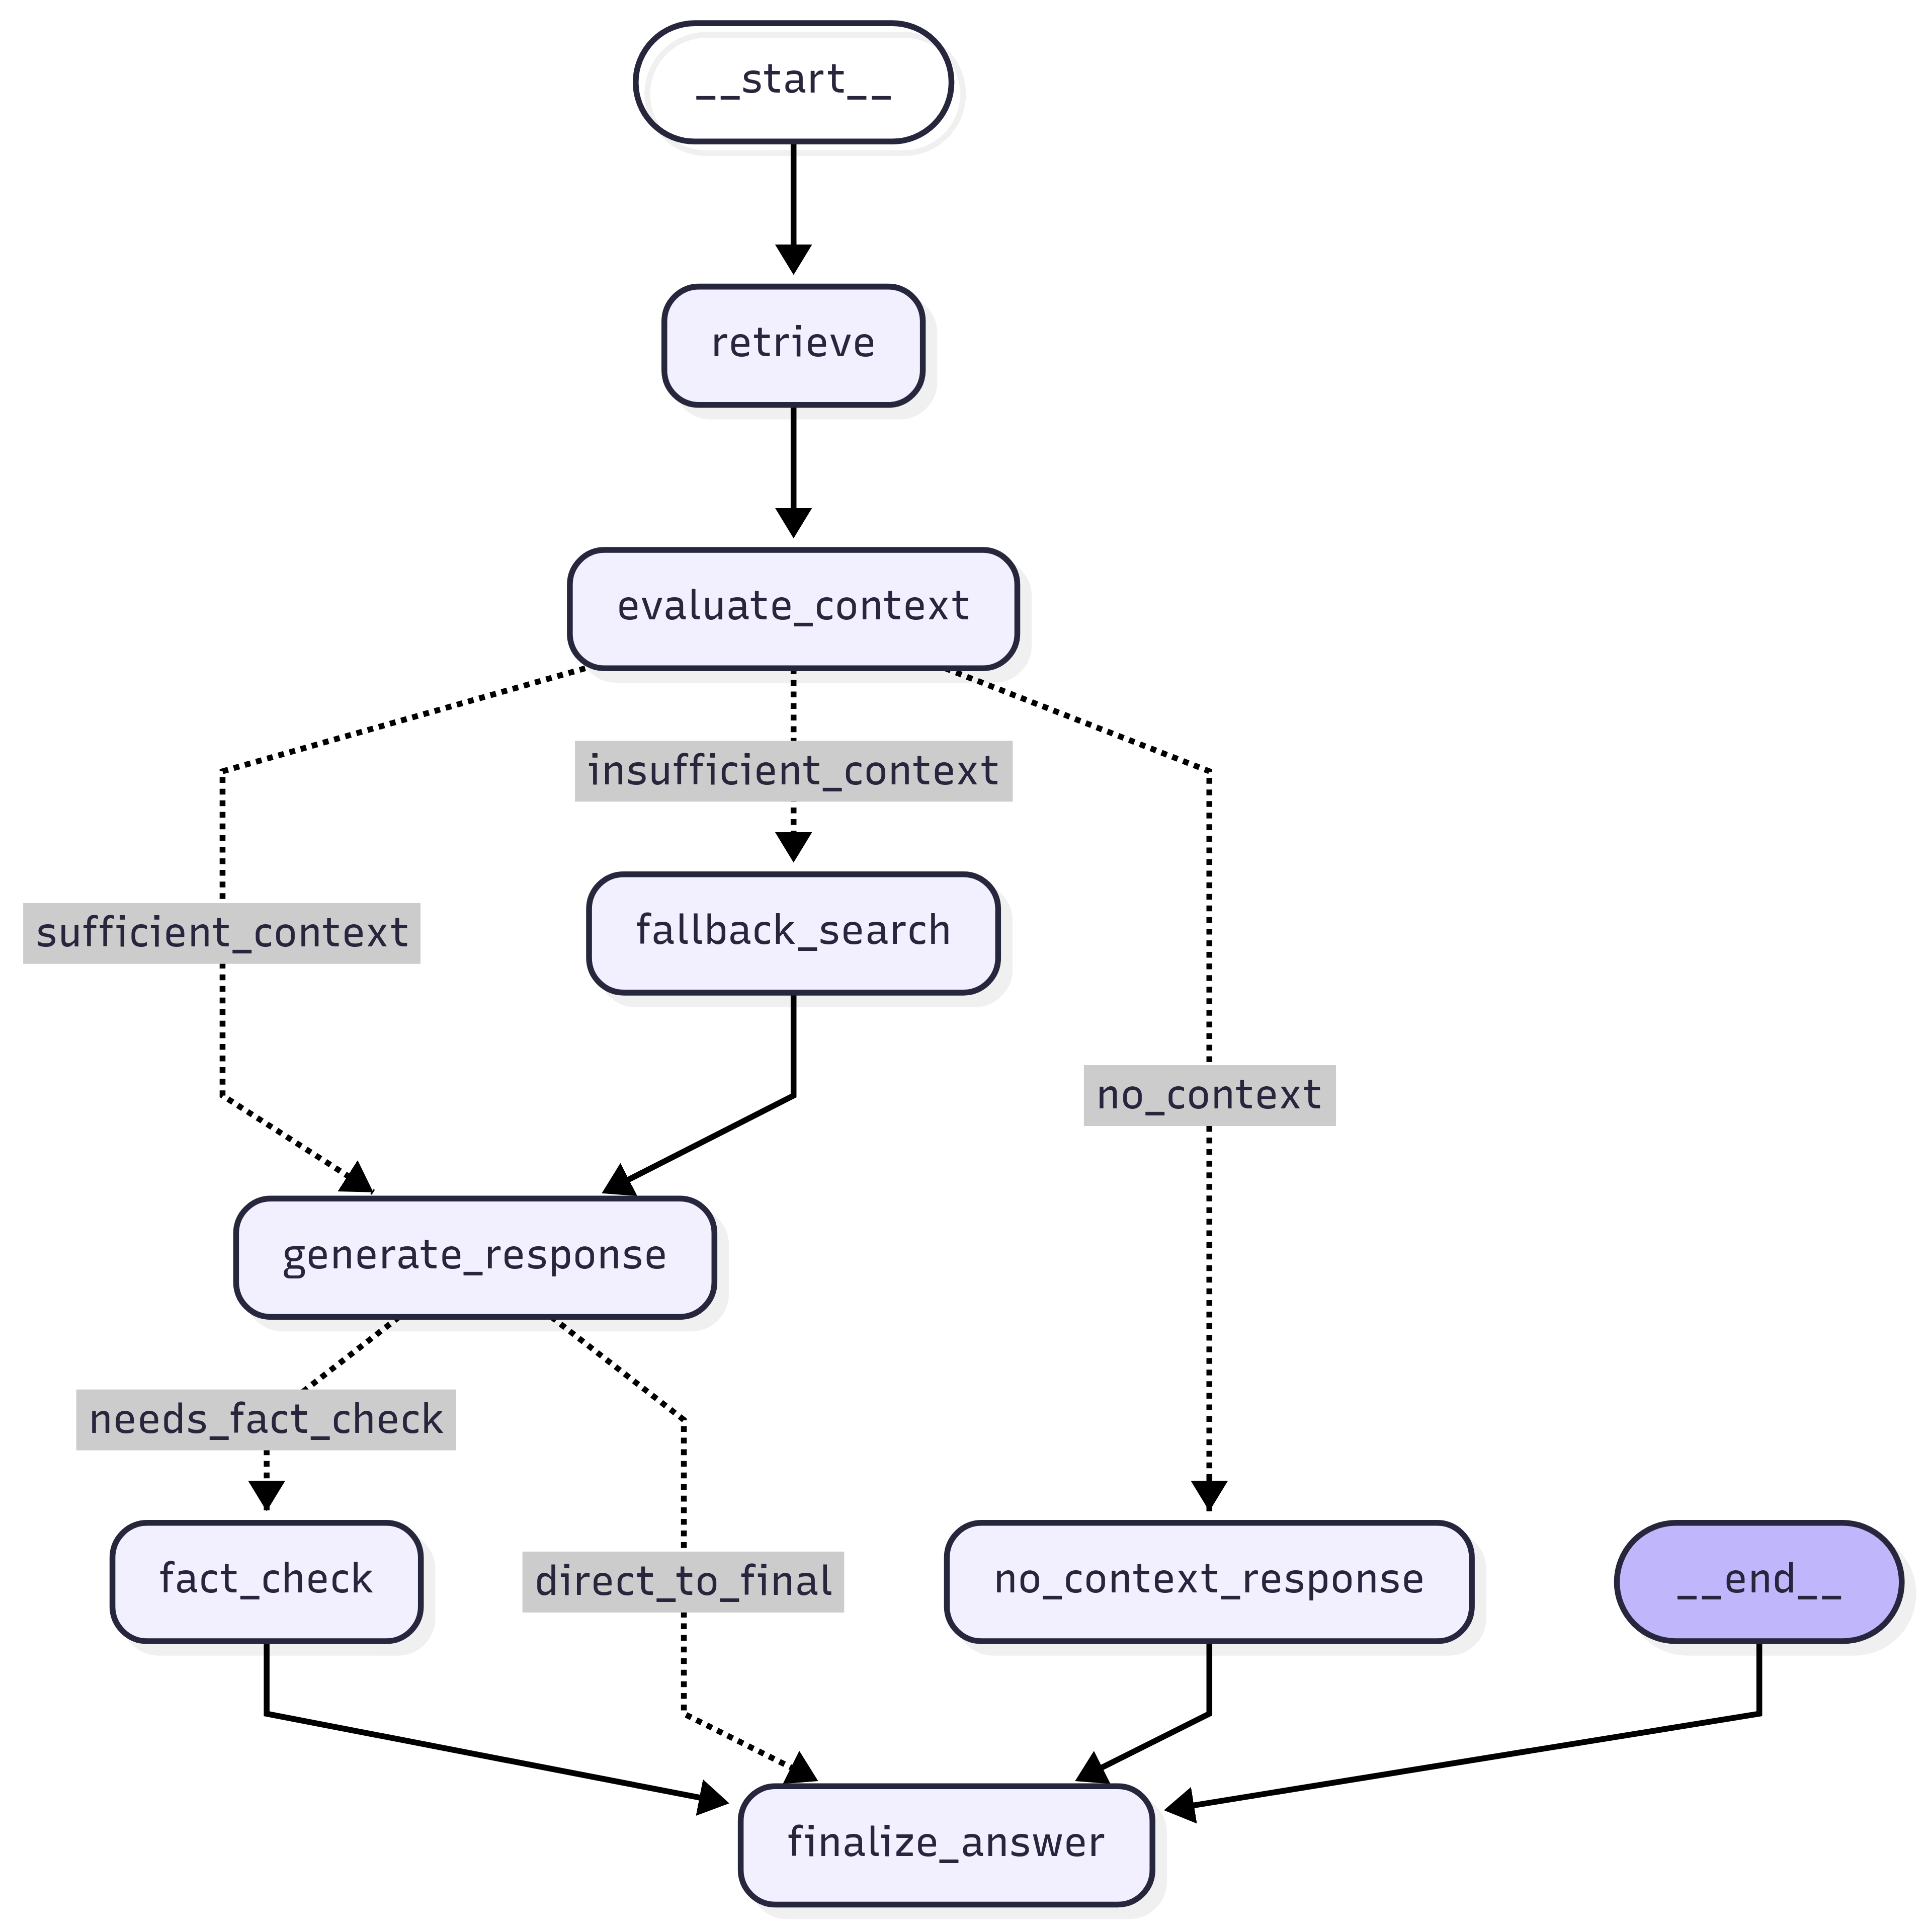

In [8]:
from IPython.display import Markdown, display, Image
display(Image(data="asset/extended_rag.png"))

In [4]:
from typing import Dict, List, Optional, Literal
from langgraph.graph import StateGraph, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.tools import DuckDuckGoSearchRun
from pydantic import BaseModel, Field
import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

class RAGState(BaseModel):
    """State object for the RAG workflow"""
    query: str = Field(..., description="The user's query")
    messages: List[BaseMessage] = Field(default_factory=list)
    retrieved_docs: List[Document] = Field(default_factory=list)
    context_relevance_score: float = Field(default=0.0)
    response: str = Field(default="")
    needs_fact_check: bool = Field(default=False)
    fact_check_result: Optional[str] = Field(default=None)
    final_answer: str = Field(default="")
    metadata: Dict = Field(default_factory=dict)


class ExtendedRAGSystem:
    def __init__(self, vector_store, llm, embeddings, relevance_threshold=0.7):
        self.vector_store = vector_store
        self.llm = llm
        self.embeddings = embeddings
        self.relevance_threshold = relevance_threshold
        self.search_tool = DuckDuckGoSearchRun()

        self.graph = self._build_graph()
    
    def __repr__(self):
        return repr(self.graph)
    
    # Or add this property
    @property
    def visual_graph(self):
        return self.graph

    def _build_graph(self):
        """Build the LangGraph workflow"""
        workflow = StateGraph(RAGState)

        # Add nodes
        workflow.add_node("retrieve", self._retrieve_documents)
        workflow.add_node("evaluate_context", self._evaluate_context_relevance)
        workflow.add_node("generate_response", self._generate_response)
        workflow.add_node("fallback_search", self._fallback_search)
        workflow.add_node("fact_check", self._fact_check_response)
        workflow.add_node("finalize_answer", self._finalize_answer)
        workflow.add_node("no_context_response", self._handle_no_context)

        workflow.set_entry_point("retrieve")

        workflow.add_edge("retrieve", "evaluate_context")

        # Conditional routing based on context quality
        workflow.add_conditional_edges(
            "evaluate_context",
            self._route_after_context_evaluation,
            {
                "sufficient_context": "generate_response",
                "insufficient_context": "fallback_search",
                "no_context": "no_context_response"
            }
        )

        # Fallback search leads to response generation
        workflow.add_edge("fallback_search", "generate_response")
        workflow.add_edge("no_context_response", "finalize_answer")

        # After generating response, decide if fact-checking is needed
        workflow.add_conditional_edges(
            "generate_response",
            self._route_after_response_generation,
            {
                "needs_fact_check": "fact_check",
                "direct_to_final": "finalize_answer"
            }
        )

        # Fact check leads to finalization
        workflow.add_edge("fact_check", "finalize_answer")
        workflow.add_edge("finalize_answer", END)

        return workflow.compile()

    def _retrieve_documents(self, state: RAGState) -> RAGState:
        """Retrieve relevant documents from vector store"""
        logger.info(f"Retrieving documents for query: {state.query}")

        try:
            docs_with_scores = self.vector_store.similarity_search_with_score(state.query, k=5)
            docs = [doc for doc, score in docs_with_scores]
            scores = [score for doc, score in docs_with_scores]

            avg_score = sum(scores) / len(scores) if scores else 0

            state.retrieved_docs = docs
            state.context_relevance_score = avg_score
            state.metadata["retrieval_scores"] = scores

            logger.info(f"Retrieved {len(docs)} documents with avg score: {avg_score:.3f}")
        
        except Exception as e:
            logger.error(f"Error in document retrieval: {e}")
            state.retrieved_docs = []
            state.context_relevance_score = 0.0
            state.metadata["retrieval_scores"] = []
        
        return state
    
    def _evaluate_context_relevance(self, state: RAGState) -> RAGState:
        """Evaluate the relevance of retrieved context"""
        if not state.retrieved_docs:
            logger.warning("No documents retrieved.")
            return state
        
        # Use LLM to evaluate context relevance
        evaluation_prompt = ChatPromptTemplate.from_template("""
        Given the user query and retrieved documents, evaluate how well the documents 
        answer the query on a scale of 0-1.
        
        Query: {query}
        
        Documents:
        {documents}
        
        Provide only a decimal score between 0 and 1, where:
        - 0.8-1.0: Excellent relevance, documents directly answer the query
        - 0.6-0.8: Good relevance, documents contain useful information
        - 0.4-0.6: Moderate relevance, some useful information but gaps exist
        - 0.0-0.4: Poor relevance, documents don't address the query well
        
        Score:
        """)
        
        docs_text = "\n\n".join([f"Doc {i+1}: {doc.page_content[:200]}..." 
                                for i, doc in enumerate(state.retrieved_docs)])

        try:
            response = self.llm.invoke(
                evaluation_prompt.format(query=state.query, documents=docs_text))
            
            score_text = response.content.strip()
            relevance_score = float(score_text)
            state.context_relevance_score = relevance_score
            
            logger.info(f"Context relevance score: {relevance_score:.3f}")
            
        except Exception as e:
            logger.error(f"Error evaluating context relevance: {e}")
            state.context_relevance_score = 0.0
        
        return state
    
    def _route_after_context_evaluation(self, state: RAGState) -> Literal["sufficient_context", "insufficient_context", "no_context"]:
        """Route based on context quality"""
        if not state.retrieved_docs:
            return "no_context"
        
        if state.context_relevance_score >= self.relevance_threshold:
            return "sufficient_context"
        
        return "insufficient_context"
    
    def _fallback_search(self, state: RAGState) -> RAGState:
        """Perform external search when context is insufficient"""
        logger.info("Performing fallback search due to insufficient context")

        try:
            search_results = self.search_tool.run(state.query)

            # Create document from search results
            fallback_doc = Document(
                page_content=search_results,
                metadata={"source": "external_search", "fallback": True}
            )
            
            # Add to retrieved docs
            state.retrieved_docs.append(fallback_doc)
            state.metadata["used_fallback_search"] = True
            
            logger.info("Added external search results to context")
            
        except Exception as e:
            logger.error(f"Fallback search failed: {e}")
            state.metadata["fallback_search_error"] = str(e)
        
        return state
    
    def _generate_response(self, state: RAGState) -> RAGState:
        """Generate a response using the retrieved context"""
        logger.info("Generating response using retrieved context")

        context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])

        # Determine if response might need fact-checking
        factual_indicators = ["statistics", "numbers", "data", "research", "study", 
                             "percentage", "rate", "according to", "report"]
        
        needs_fact_check = any(indicator in state.query.lower() or 
                              indicator in context.lower() 
                              for indicator in factual_indicators)
        
        state.needs_fact_check = needs_fact_check
        
        response_prompt = ChatPromptTemplate.from_template("""
        You are a helpful assistant. Use the provided context to answer the user's query.
        If the context doesn't fully address the query, acknowledge this limitation.
        
        Context:
        {context}
        
        query: {query}
        
        Instructions:
        - Be accurate and cite specific information from the context when possible
        - If making claims about facts, numbers, or statistics, be especially careful
        - Acknowledge if the context is limited or if you're uncertain
        - Provide a clear, well-structured response
        
        Answer:
        """)
        
        try:
            response = self.llm.invoke(response_prompt.format(
                context=context,
                query=state.query
            ))
            
            state.response = response.content
            state.messages.append(AIMessage(content=response.content))
            
            logger.info("Generated response from available context")
            
        except Exception as e:
            logger.error(f"Error generating response: {e}")
            state.response = "I apologize, but I encountered an error generating a response."
        
        return state
    
    def _route_after_response_generation(self, state: RAGState) -> Literal["needs_fact_check", "direct_to_final"]:
        """Route based on whether fact-checking is needed"""
        return "needs_fact_check" if state.needs_fact_check else "direct_to_final"
    
    def _fact_check_response(self, state: RAGState) -> RAGState:
        """Fact-check the generated response"""
        logger.info("Performing fact-checking on response")
        
        fact_check_prompt = ChatPromptTemplate.from_template("""
        Review the following response for factual accuracy. Look for:
        - Specific claims that might need verification
        - Statistical or numerical information
        - References to studies, reports, or authoritative sources
        
        Original Query: {query}
        Response to Check: {response}
        
        Provide your fact-check assessment:
        1. Are there any claims that seem queryable or need verification?
        2. Are numerical/statistical claims properly qualified?
        3. Overall confidence level in the response accuracy (High/Medium/Low)
        
        If you identify issues, suggest how to improve the response.
        
        Assessment:
        """)
        
        try:
            fact_check_response = self.llm.invoke(fact_check_prompt.format(
                query=state.query,
                response=state.response
            ))
            
            state.fact_check_result = fact_check_response.content
            state.metadata["fact_checked"] = True
            
            logger.info("Fact-check completed")
            
        except Exception as e:
            logger.error(f"Error during fact-checking: {e}")
            state.fact_check_result = "Fact-check could not be completed due to an error."
        
        return state
    
    def _handle_no_context(self, state: RAGState) -> RAGState:
        """Handle cases where no relevant context is found"""
        logger.info("Handling no context scenario")
        
        no_context_prompt = ChatPromptTemplate.from_template("""
        The user asked: "{query}"
        
        Unfortunately, I couldn't find relevant information in my knowledge base to answer this query.
        
        Please provide a helpful response that:
        1. Acknowledges that you don't have specific information about their query
        2. Suggests alternative ways they might find the information they need
        3. Offers to help with related topics if possible
        4. Remains helpful and encouraging
        
        Response:
        """)
        
        try:
            response = self.llm.invoke(no_context_prompt.format(query=state.query))
            state.response = response.content
            state.metadata["no_context_handled"] = True
            
        except Exception as e:
            logger.error(f"Error handling no context: {e}")
            state.response = """I apologize, but I couldn't find relevant information to answer your query in my knowledge base. 
            You might want to try rephrasing your query or consulting other sources for this specific information."""
        
        return state
    
    def _finalize_answer(self, state: RAGState) -> RAGState:
        """Finalize the answer, potentially incorporating fact-check results"""
        if state.fact_check_result and "Low" in state.fact_check_result:
            # If fact-check indicates low confidence, add a disclaimer
            disclaimer = "\n\n*Please note: This response contains information that should be independently verified.*"
            state.final_answer = state.response + disclaimer
        else:
            state.final_answer = state.response
        
        # Add metadata about the process
        process_info = []
        if state.metadata.get("used_fallback_search"):
            process_info.append("external search")
        if state.metadata.get("fact_checked"):
            process_info.append("fact-checked")
        if state.metadata.get("no_context_handled"):
            process_info.append("no relevant context found")
        
        if process_info:
            state.metadata["process_summary"] = ", ".join(process_info)
        
        logger.info(f"Finalized answer. Process: {state.metadata.get('process_summary', 'standard flow')}")
        
        return state
    
    def query(self, query: str) -> Dict:
        """Main query method"""
        initial_state = RAGState(
            query=query,
            messages=[HumanMessage(content=query)]
        )
        
        # Run the graph
        final_state = self.graph.invoke(initial_state)
        
        return {
            "answer": final_state['final_answer'],
            "metadata": final_state['metadata'],
            "context_docs": len(final_state['retrieved_docs']),
            "relevance_score": final_state['context_relevance_score']
        }

# Example usage and setup
def setup_extended_rag_system():
    """Setup function for the extended RAG system"""
    
    # Initialize components (you'll need to adapt these to your setup)
    llm = ChatOpenAI(model="gpt-4", temperature=0)
    embeddings = OpenAIEmbeddings()
    
    # For demo purposes, create a mock vector store
    class MockVectorStore:
        def similarity_search_with_score(self, query, k=5):
            # Return empty results to demonstrate no-context handling
            if "unknown topic" in query.lower():
                return []
            
            # Return mock documents with scores
            mock_docs = [
                (Document(page_content=f"Mock document about {query}", 
                         metadata={"source": "mock"}), 0.8),
                (Document(page_content=f"Additional context for {query}", 
                         metadata={"source": "mock"}), 0.7)
            ]
            return mock_docs

        def similarity_search(self, query, k=5):
            """Fallback method that some parts of the code might expect"""
            docs_with_scores = self.similarity_search_with_score(query, k)
            return [doc for doc, score in docs_with_scores]
    
    vector_store = MockVectorStore()
    
    # Create the extended RAG system
    rag_system = ExtendedRAGSystem(
        vector_store=vector_store,
        llm=llm,
        embeddings=embeddings,
        relevance_threshold=0.7
    )
    
    return rag_system

# Example queries to test different scenarios
if __name__ == "__main__":
    rag_system = setup_extended_rag_system()
    
    # Test different scenarios
    test_queries = [
        "What are the latest statistics on renewable energy adoption?",  # Should trigger fact-checking
        "Tell me about an unknown topic that doesn't exist",  # Should trigger no-context handling
        "How does photosynthesis work?",  # Normal query with sufficient context
    ]
    
    for query in test_queries:
        print(f"\n{'='*60}")
        print(f"Query: {query}")
        print(f"{'='*60}")
        
        result = rag_system.query(query)
        
        print(f"Answer: {result['answer']}")
        print(f"Metadata: {result['metadata']}")
        print(f"Context docs: {result['context_docs']}")
        print(f"Relevance score: {result['relevance_score']:.3f}")

INFO:__main__:Retrieving documents for query: What are the latest statistics on renewable energy adoption?
INFO:__main__:Retrieved 2 documents with avg score: 0.750



Query: What are the latest statistics on renewable energy adoption?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Context relevance score: 1.000
INFO:__main__:Generating response using retrieved context
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Generated response from available context
INFO:__main__:Performing fact-checking on response
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Fact-check completed
INFO:__main__:Finalized answer. Process: fact-checked
INFO:__main__:Retrieving documents for query: Tell me about an unknown topic that doesn't exist
INFO:__main__:Retrieved 0 documents with avg score: 0.000
INFO:__main__:Handling no context scenario


Answer: I'm sorry, but I can't provide the latest statistics on renewable energy adoption as the context provided does not include any specific data or information.
Metadata: {'retrieval_scores': [0.8, 0.7], 'fact_checked': True, 'process_summary': 'fact-checked'}
Context docs: 2
Relevance score: 1.000

Query: Tell me about an unknown topic that doesn't exist


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Finalized answer. Process: no relevant context found
INFO:__main__:Retrieving documents for query: How does photosynthesis work?
INFO:__main__:Retrieved 2 documents with avg score: 0.750


Answer: I'm sorry, but as you've asked about a topic that doesn't exist, it's quite challenging for me to provide specific information. However, if you're interested in exploring new or less-known topics, I'd suggest browsing through academic journals or online forums that cater to unique and niche subjects. Alternatively, if you have any other questions or need information on a different topic, I'd be more than happy to assist. Remember, no question is too big or small, and I'm here to help you find the answers you need.
Metadata: {'retrieval_scores': [], 'no_context_handled': True, 'process_summary': 'no relevant context found'}
Context docs: 0
Relevance score: 0.000

Query: How does photosynthesis work?


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Context relevance score: 1.000
INFO:__main__:Generating response using retrieved context
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Generated response from available context
INFO:__main__:Finalized answer. Process: standard flow


Answer: I'm sorry, but the provided context does not give any specific information about how photosynthesis works. However, generally, photosynthesis is a process used by plants and other organisms to convert light energy, usually from the sun, into chemical energy that can be later released to fuel the organisms' activities. This process involves several steps, including light-dependent reactions and the Calvin cycle. For a more detailed explanation, additional context or resources would be needed.
Metadata: {'retrieval_scores': [0.8, 0.7]}
Context docs: 2
Relevance score: 1.000


In [6]:
# Test just one query
result = rag_system.query("Tell me about an unknown topic that doesn't exist")
print(result)

INFO:__main__:Retrieving documents for query: Tell me about an unknown topic that doesn't exist
INFO:__main__:Retrieved 0 documents with avg score: 0.000
INFO:__main__:Handling no context scenario
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:__main__:Finalized answer. Process: no relevant context found


{'answer': "I'm sorry, but as you've asked about a topic that doesn't exist, I'm unable to provide specific information. However, if you're interested in exploring new or less-known topics, I'd suggest doing some online research or checking out educational platforms that cover a wide range of subjects. If you have any other questions or need information on a different topic, feel free to ask. I'm here to help!", 'metadata': {'retrieval_scores': [], 'no_context_handled': True, 'process_summary': 'no relevant context found'}, 'context_docs': 0, 'relevance_score': 0.0}


In [62]:
try:
    # Generate PNG image of the graph
    graph_image = rag_system.graph.get_graph().draw_mermaid_png()
    display(Image(graph_image))
except Exception as e:
    print(f"Mermaid PNG failed: {e}")
    print("You may need to install: pip install pygraphviz")

Mermaid PNG failed: Failed to reach https://mermaid.ink/ API while trying to render your graph. Status code: 502.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`
You may need to install: pip install pygraphviz


In [67]:
print(rag_system.graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	retrieve(retrieve)
	evaluate_context(evaluate_context)
	generate_response(generate_response)
	fallback_search(fallback_search)
	fact_check(fact_check)
	finalize_answer(finalize_answer)
	no_context_response(no_context_response)
	__end__([<p>__end__</p>]):::last
	__start__ --> retrieve;
	evaluate_context -. &nbsp;insufficient_context&nbsp; .-> fallback_search;
	evaluate_context -. &nbsp;sufficient_context&nbsp; .-> generate_response;
	evaluate_context -. &nbsp;no_context&nbsp; .-> no_context_response;
	fact_check --> finalize_answer;
	fallback_search --> generate_response;
	generate_response -. &nbsp;needs_fact_check&nbsp; .-> fact_check;
	generate_response -. &nbsp;direct_to_final&nbsp; .-> finalize_answer;
	no_context_response --> finalize_answer;
	retrieve --> evaluate_context;
	finalize_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	clas